<a href="https://colab.research.google.com/github/HLZHarry/Alpha-Lens-TPM/blob/main/04_Backtest_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.  The Brain (XGBoost): We use a Gradient Boosted Tree model to find the mathematical relationship between your features (Momentum, Volatility, AI Sentiment) and the future return.

2.  The Proof (Backtest): We simulate how a portfolio would have performed if it followed the AI's "buy/sell" signals in the real world.

📈 The Expected Outcome

A Comparison Chart (Equity Curve). You should see two lines:

1. The Benchmark (Gray/Dotted): The "Buy and Hold" return of your stock universe.

2. The Hybrid Strategy (Blue/Solid): Your AI-driven portfolio.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [2]:
# 1. LOAD DATA
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Alpha-Lens-Project"
df = pd.read_csv(f"{path}/final_hybrid_data_v3.csv")
df['Date'] = pd.to_datetime(df['Date'])

Mounted at /content/drive


In [3]:
df.head(5)

,Date,Ticker,Price,Log_Return,Momentum_1M,Vol_1M,Target_Next_Return,RSI,MA200,Price_to_MA200,Intraday_Var,AI_Sentiment
0,2021-10-18,AAPL,143.195755,0.011737,0.003350,0.012911,0.014967,62.159408,132.270017,1.082602,0.000141,0.0
1,2021-10-18,CVX,91.270325,-0.000456,0.124238,0.013860,0.019344,72.431116,82.952576,1.100271,0.000019,0.0
2,2021-10-18,GOOGL,141.707291,0.009924,0.013950,0.015363,0.003210,64.660737,117.850202,1.202436,0.000249,0.0
3,2021-10-18,GS,369.896729,0.018591,0.055234,0.019071,-0.003705,66.254435,316.413994,1.169028,0.000223,0.0
4,2021-10-18,JNJ,140.744308,-0.007342,-0.028506,0.007505,0.023150,41.882831,144.384060,0.974791,0.000123,0.0


In [4]:
# 2. Feature Selection
# We use our Momentum, Volatility, and teh OpenAI Sentiment score
features = ['Momentum_1M', 'Vol_1M', 'AI_Sentiment', 'RSI', 'Price_to_MA200']
target = 'Target_Next_Return'

In [5]:
# 3. Time-Series Split (The 'Gold Standard' for Finance)
# We train on data before 2025 and test on 2025-2026 (The 'Future')
train_df = df[df['Date'] < '2025-01-01'].dropna()
test_df = df[df['Date'] >= '2025-01-01'].copy().dropna()

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

In [6]:
# 4. Train The XGBosst model
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.01,
    subsample = 0.8,
    colsample_bytree=0.8,
    objective = 'reg:squarederror'
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
# 5. Generate Predictions & Strategy
test_df['Predicted_Return'] = model.predict(X_test)

# Strategy Logic: If prediction is positive, go 'Long' (1), else Cash (0)
threshold = test_df['Predicted_Return'].std()*0.1
test_df['Signal'] = np.where(test_df['Predicted_Return'] > threshold, 1, 0)
test_df['Strategy_Return'] = test_df['Signal'] * test_df['Log_Return']

In [8]:
# 6. Calculate Cumulative Returns (Performance)
# Group by date to see the Average performance
market_performance = test_df.groupby('Date')['Log_Return'].mean().cumsum().apply(np.exp)
strategy_performance = test_df.groupby('Date')['Strategy_Return'].mean().cumsum().apply(np.exp)

In [11]:
# 7. CALCULATE SCALAR METRICS (FOR LABELS)
def get_sharpe(returns):
    return (returns.mean() / returns.std()) * np.sqrt(252)

# We calculate these as single numbers so the :.2f formatting works
m_returns = test_df.groupby('Date')['Log_Return'].mean()
s_returns = test_df.groupby('Date')['Strategy_Return'].mean()

m_sharpe = get_sharpe(m_returns)
s_sharpe = get_sharpe(s_returns)

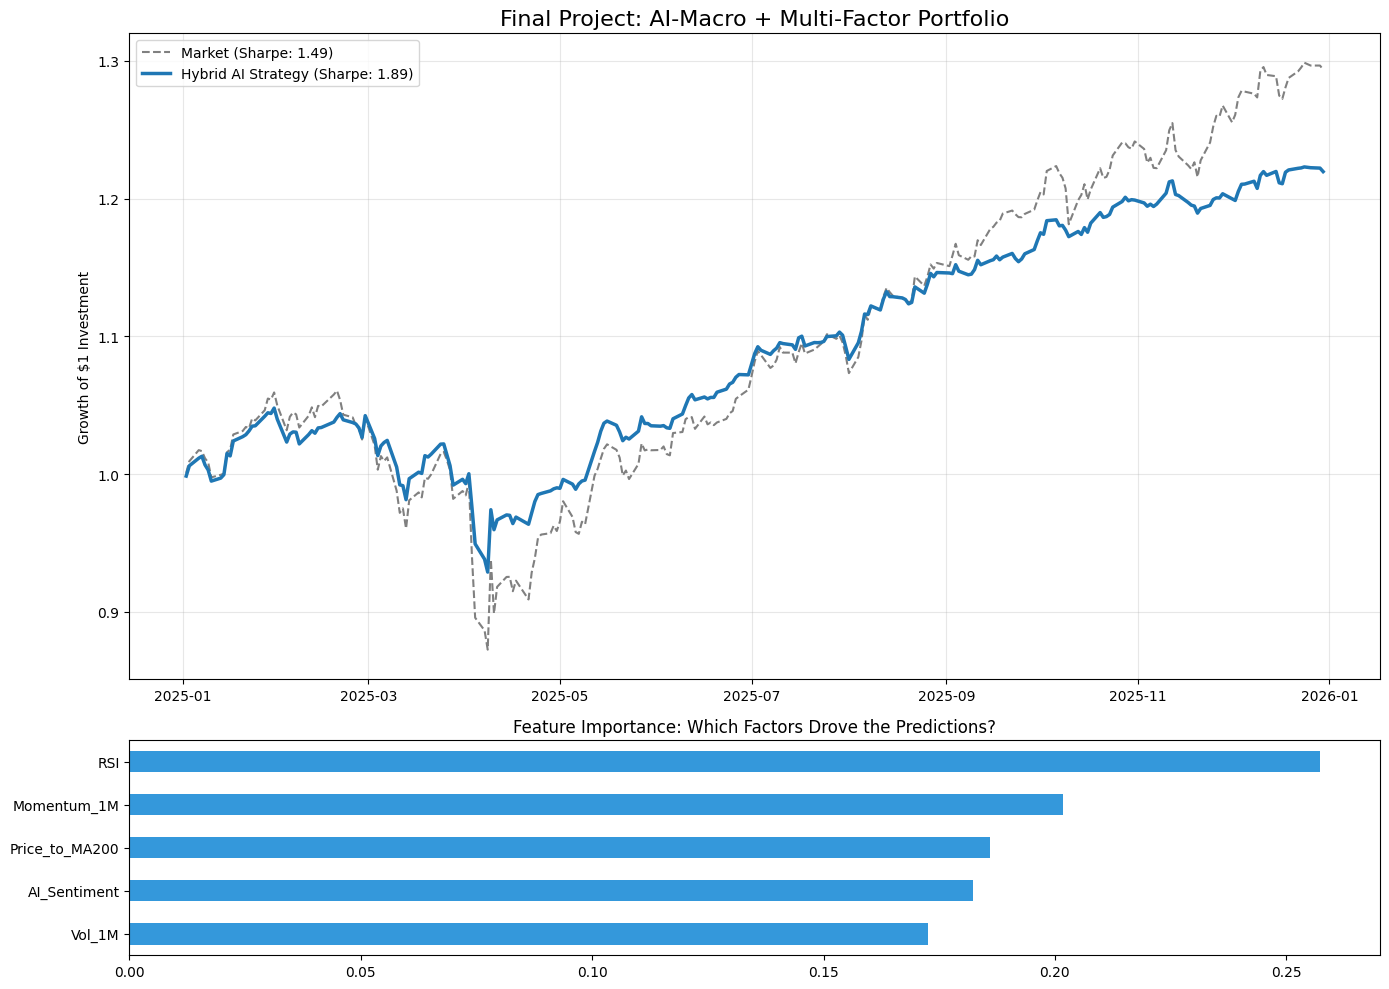

Final Strategy Sharpe: 1.89
Market Benchmark Sharpe: 1.49


In [14]:
# 6. Visulization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve - Now using the single sharpe numbers
ax1.plot(market_performance, label=f'Market (Sharpe: {m_sharpe:.2f})', color='gray', linestyle='--')
ax1.plot(strategy_performance, label=f'Hybrid AI Strategy (Sharpe: {s_sharpe:.2f})', color='#1f77b4', linewidth=2.5)
ax1.set_title('Final Project: AI-Macro + Multi-Factor Portfolio', fontsize=16)
ax1.set_ylabel('Growth of $1 Investment')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=ax2, color='#3498db')
ax2.set_title('Feature Importance: Which Factors Drove the Predictions?')

plt.tight_layout()
plt.show()

print(f"Final Strategy Sharpe: {s_sharpe:.2f}")
print(f"Market Benchmark Sharpe: {m_sharpe:.2f}")

In [15]:
# 8. OUTPUT METRICS
total_return = (strategy_performance.iloc[-1] - 1) * 100
market_return = (market_performance.iloc[-1] - 1) * 100
print(f"Total Strategy Return: {total_return:.2f}%")
print(f"Total Market Return: {market_return:.2f}%")

Total Strategy Return: 21.97%
Total Market Return: 29.37%
